In [2]:
import re
import os
import matplotlib.pyplot as plt
import numpy as np
import math
import pandas as pd
from io import StringIO
from scipy.interpolate import CubicSpline, interp1d
params = {
          'font.size' : 10,
          }
        #   'font.family' : 'qhv',
plt.rcParams.update(params)

In [3]:
def get_sorted(dic):
    return [dic[k] for k in list(map(str,sorted(list(map(int, dic.keys())))))]

def get_betas(folder):
    betas = {}
    pattern = re.compile(r"Beta \s=\s(?P<value>[0-9]*\.[0-9]*)")
    for run in [f for f in next(os.walk(folder))[1] if f != 'lightning_logs']:
        n_run = run.split('_')[-1]
        with open(os.path.join(folder,run,'out.txt')) as f:
            txt = f.read()
            match  = pattern.search(txt)
            if match is not None:
                betas[n_run] = match.group('value')
    return betas


def get_correlations(folder):
    corr = {}
    for run in [f for f in next(os.walk(folder))[1] if f != 'lightning_logs']:
        n_run = run.split('_')[-1]
        filename = os.path.join(folder,run,'out.txt')
        corrs = read_correlations(filename)
        corr[n_run] = corrs
    return corr


def read_one_correlations(lines, delimiter_char='='):

    start_line = -1
    end_line = -1
    for i in range(len(lines)):
        if lines[i].strip() == delimiter_char * len(lines[i].strip()):
            if start_line == -1:
                start_line = i
            else:
                end_line = i
                break

    if start_line != -1 and end_line != -1:
        data = ''.join(lines[start_line+1:end_line])
        data = data.replace("Latent Dimension 0", "Latent-Dimension-0")
        data = data.replace("Latent Dimension 1", "Latent-Dimension-1")
        return pd.read_csv(StringIO(data), sep=r"\s+", engine='python', index_col = 0)
    else:
        raise Exception("Could not find correlations in file.")


def read_correlations(filename, delimiter_char='='):

    with open(filename, 'r') as file:
        lines = file.readlines()
    corr_list = []
    for i in range(len(lines)):
        if "Correlation of latent space and labels" in lines[i]:
            corr_list.append(read_one_correlations(lines[i:], delimiter_char))
    return corr_list

def get_outfile_section(filename, header_string, occurence=-1):
    with open(filename, 'r') as file:
        lines = file.readlines()
    occurances = []
    for ind,line in enumerate(lines):
        if header_string in line:
            occurances.append(ind)
    if len(occurances) == 0:
        raise Exception("Could not find header string in file.")
    read_head = occurances[occurence] + 2
    if len(lines) <= read_head:
        raise Exception("Could not find end of section.")
    line = lines[read_head]
    result = []
    while '=====' not in line:
        result.append(line)
        read_head += 1
        if len(lines) <= read_head:
            Exception("Could not find end of section.")
        line = lines[read_head]
    for i in range(len(result)):
        result[i] = re.sub('Latent Dimension ([0-9]+)', 'LD-\\1', result[i])
    return result

def read_correlations_from_file(filename):
    data = get_outfile_section(filename, "Correlation of latent space and labels")
    header = data[0].strip().split()
    df = pd.read_csv(StringIO('\n'.join(data[1:])), sep=r"\s+", engine='python', index_col = 0, header=None)
    df.columns = header
    return df



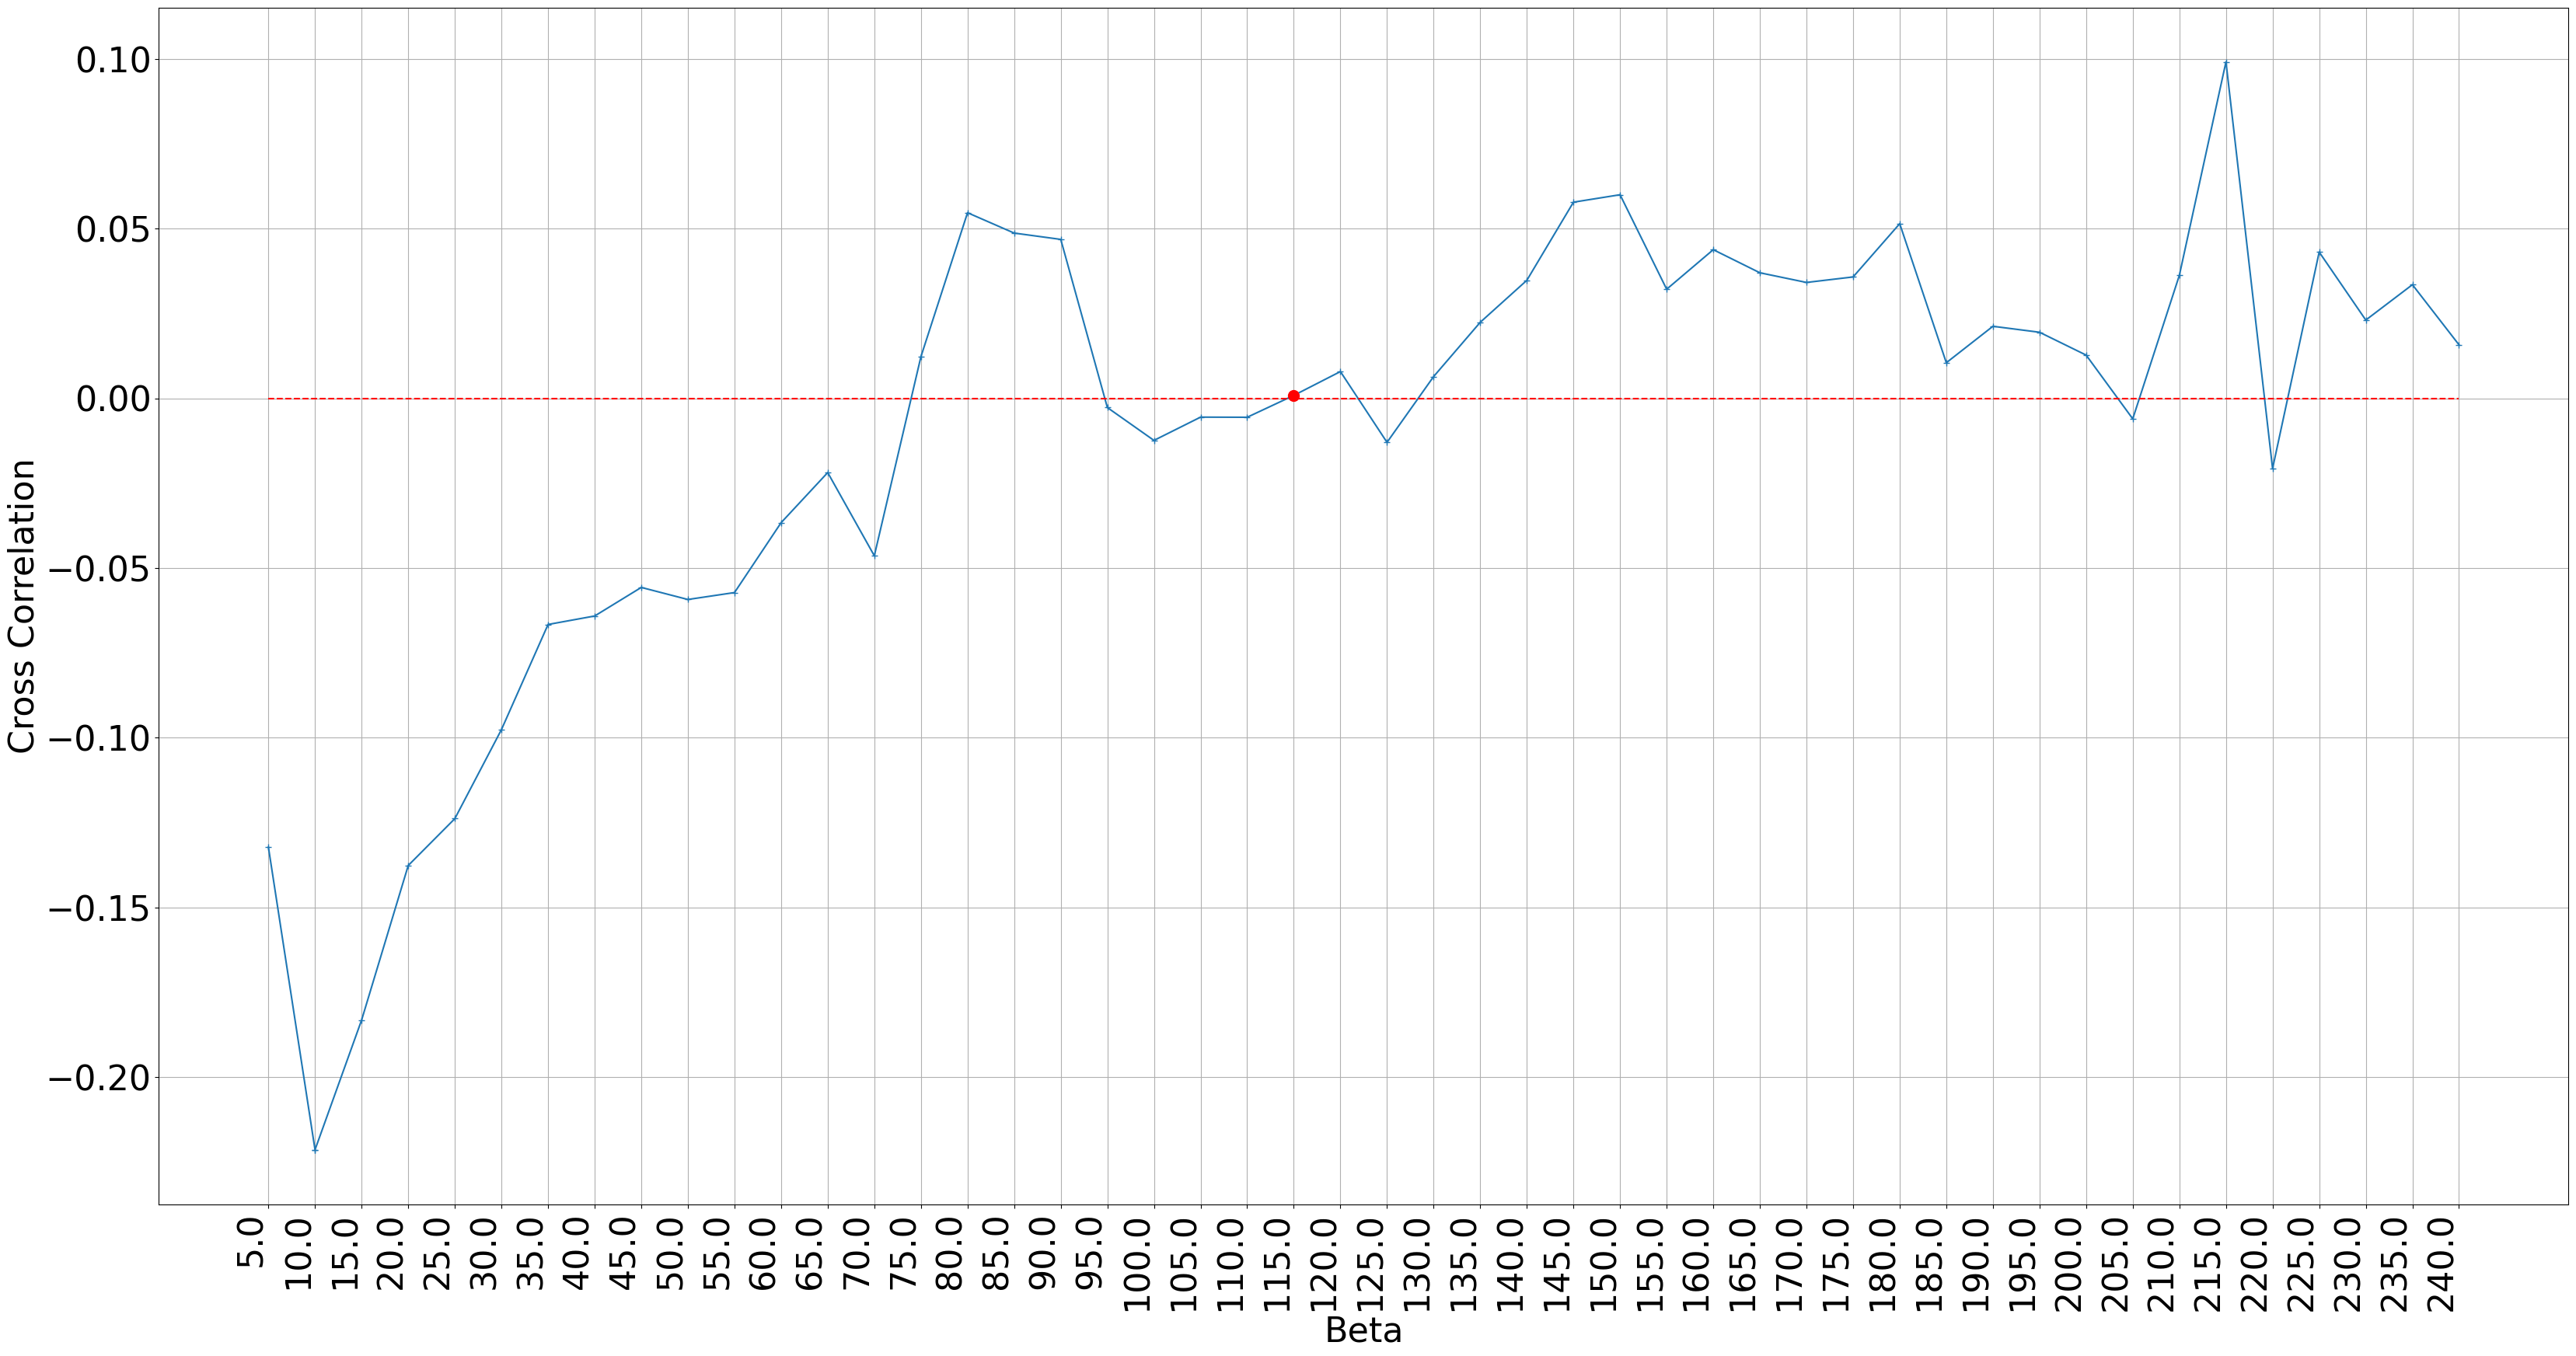

In [10]:
plt.rcParams["figure.figsize"] = (40,20)
plt.rcParams.update({'font.size': 32})
plt.xticks(rotation=90, ha='right')
folder = os.path.join(os.getcwd() +'/saved_runs/beta_search_500_elbo_2/')
all_corrs = get_correlations(folder)
all_betas = get_betas(folder)
correlations = []
betas = []
label_corrs = []
keylists = list(map(int, all_corrs.keys()))
keylists.sort()
keylists = list(map(str, keylists))[:50]
for run in keylists:
    if len(all_corrs[run]) > 0:
        correlations.append(all_corrs[run][-1].iloc[0,1])
        betas.append(all_betas[run])
        label_corrs.append([all_corrs[run][-1].iloc[0,2], all_corrs[run][-1].iloc[0,3], all_corrs[run][-1].iloc[1,2], all_corrs[run][-1].iloc[1,3]])
plt.plot(betas, correlations, '+-')
minarg = np.argmin(np.abs([f if not math.isnan(f) else 1 for f in correlations]))
plt.plot(betas[minarg],correlations[minarg], 'ro', markersize=10)
plt.plot(betas,[0] * len(betas),'--', color='red')
plt.xlabel('Beta')
plt.ylabel('Cross Correlation')
plt.grid()

# correlations

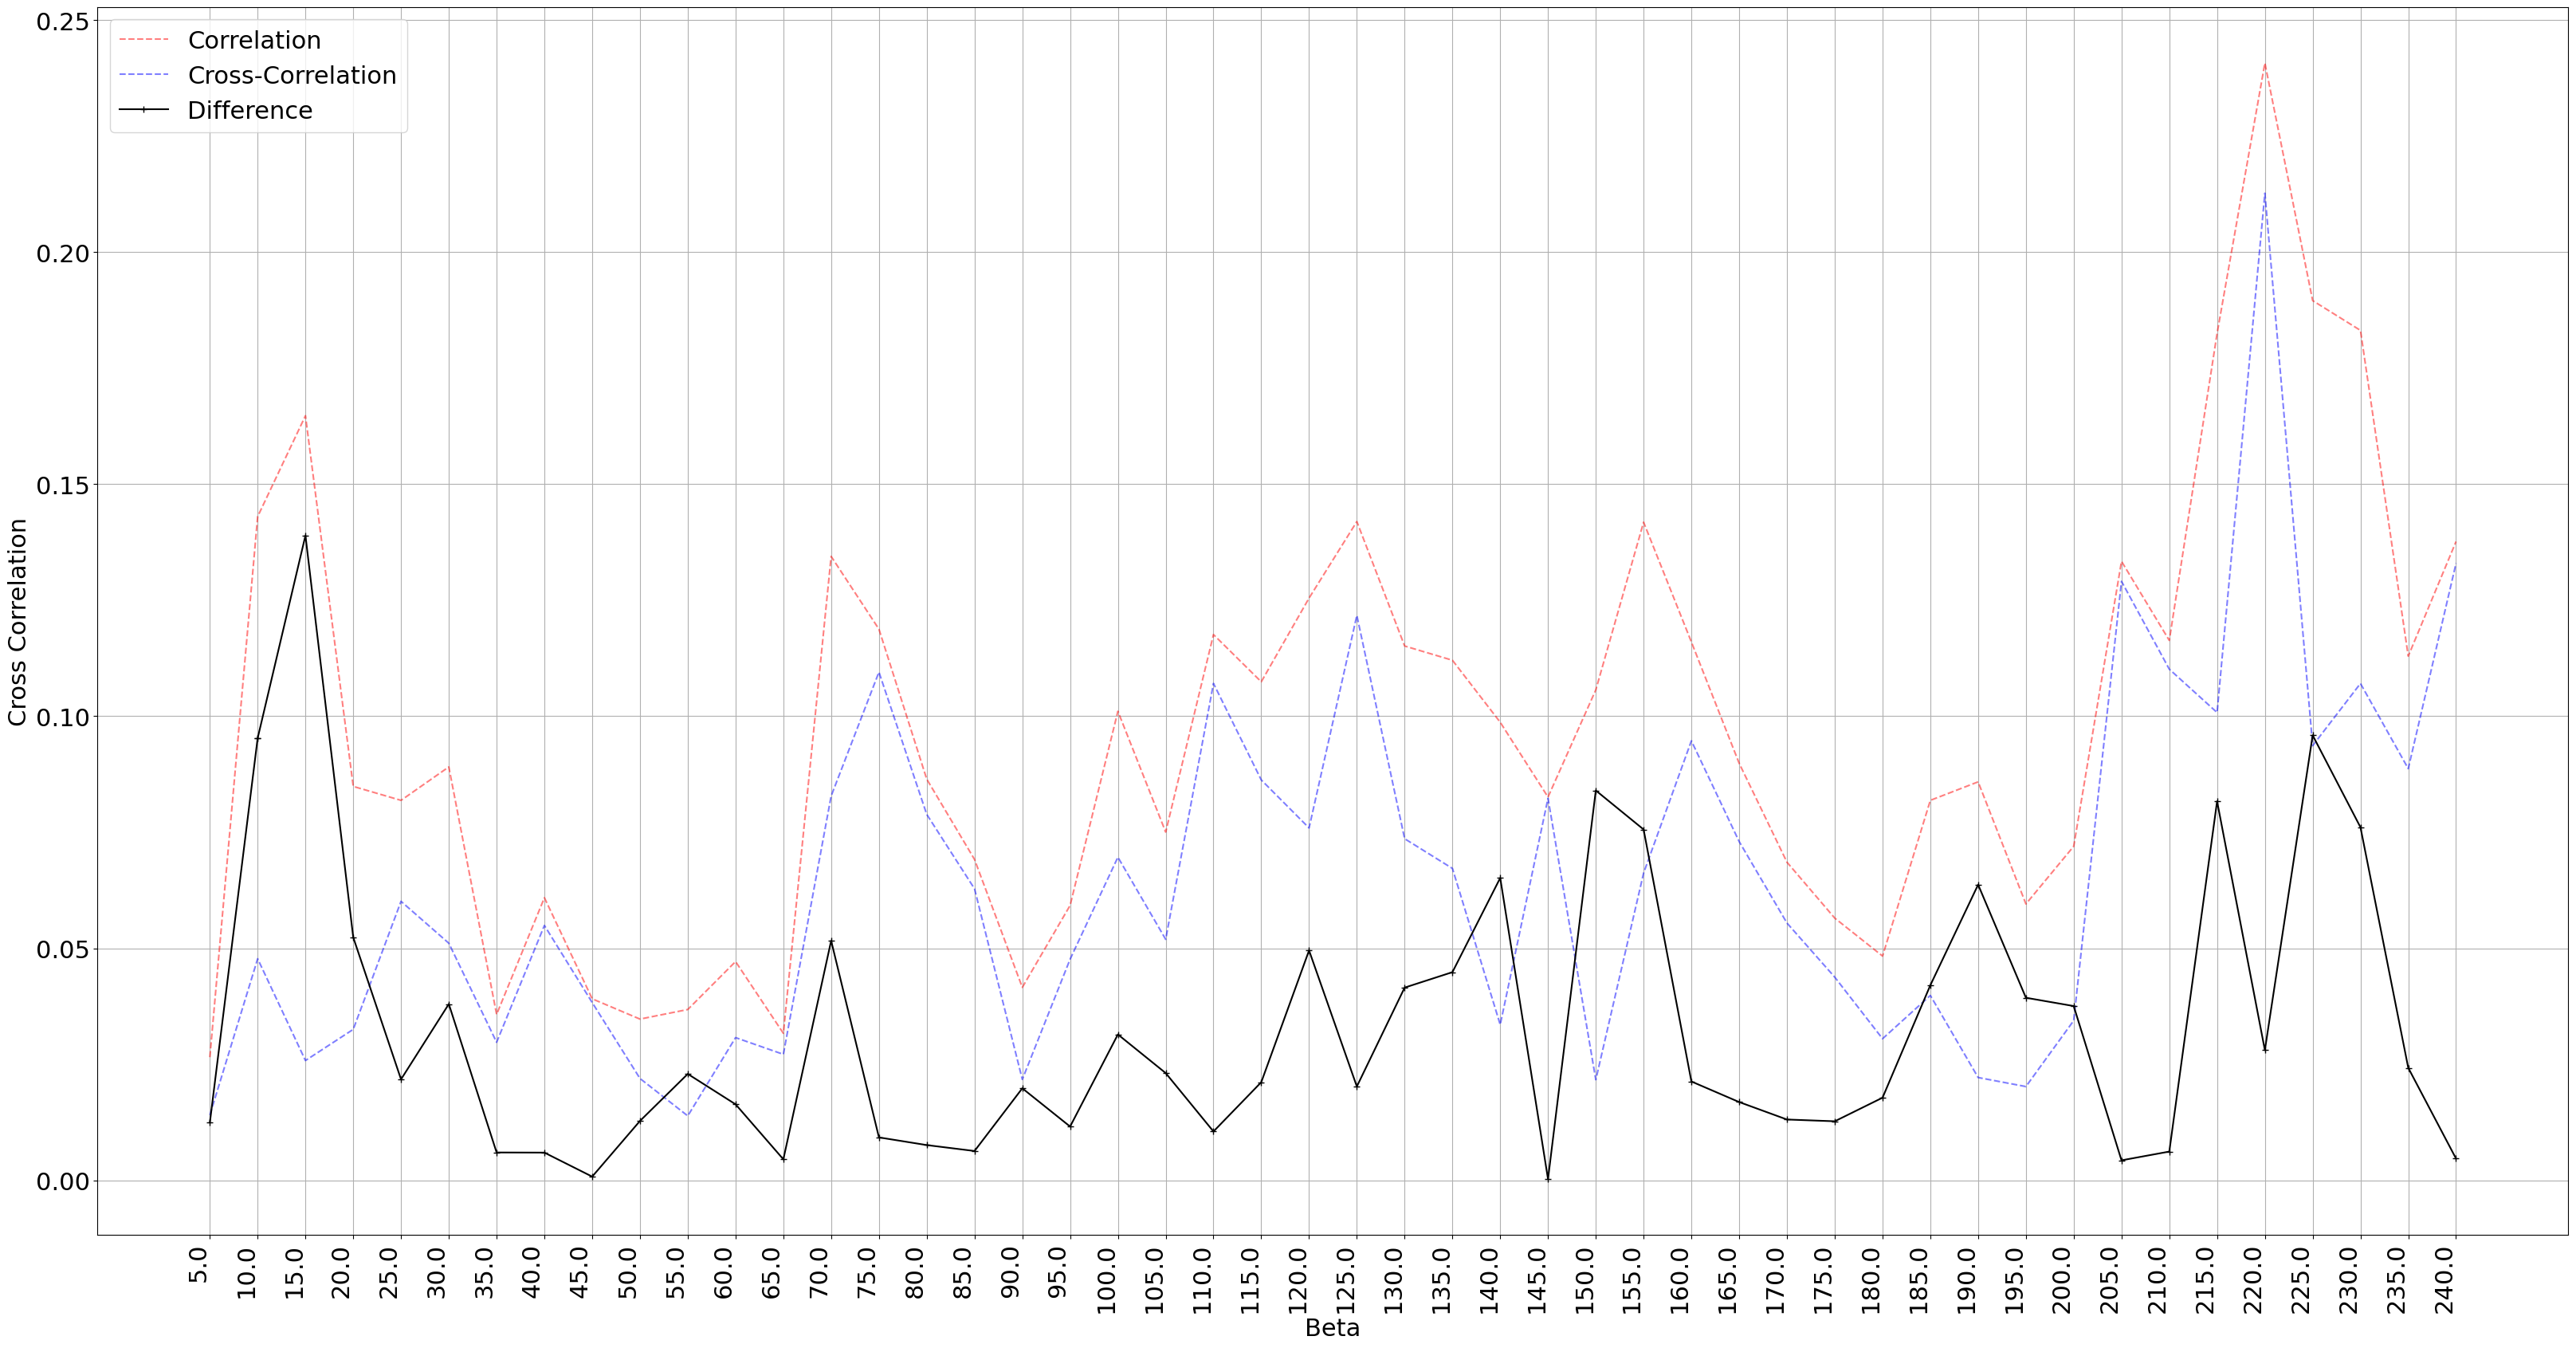

In [143]:
plt.close()
plt.rcParams["figure.figsize"] = (40,20)
plt.rcParams.update({'font.size': 22})
plt.xticks(rotation=90, ha='right')
corr = []
cross = []
for values in label_corrs:
    if True in [math.isnan(val) for val in values]:
        corr.append(float('nan'))
        cross.append(float('nan'))
    else:
        v1 = abs(values[0])+abs(values[3])
        v2 = abs(values[1])+abs(values[2])
        corr.append(max(v1,v2))
        cross.append(min(v1,v2))
diff  = [x-y for x,y in zip(corr,cross)]
plt.plot(betas,corr, 'r--', label='Correlation', alpha=0.5)
plt.plot(betas,cross, 'b--', label='Cross-Correlation', alpha=0.5)
plt.plot(betas,diff, '+-', color='black', label='Difference')
plt.xlabel('Beta')
plt.ylabel('Cross Correlation')
plt.grid()
plt.legend()

# Plot beta vs avg.sd of latent space dimensions

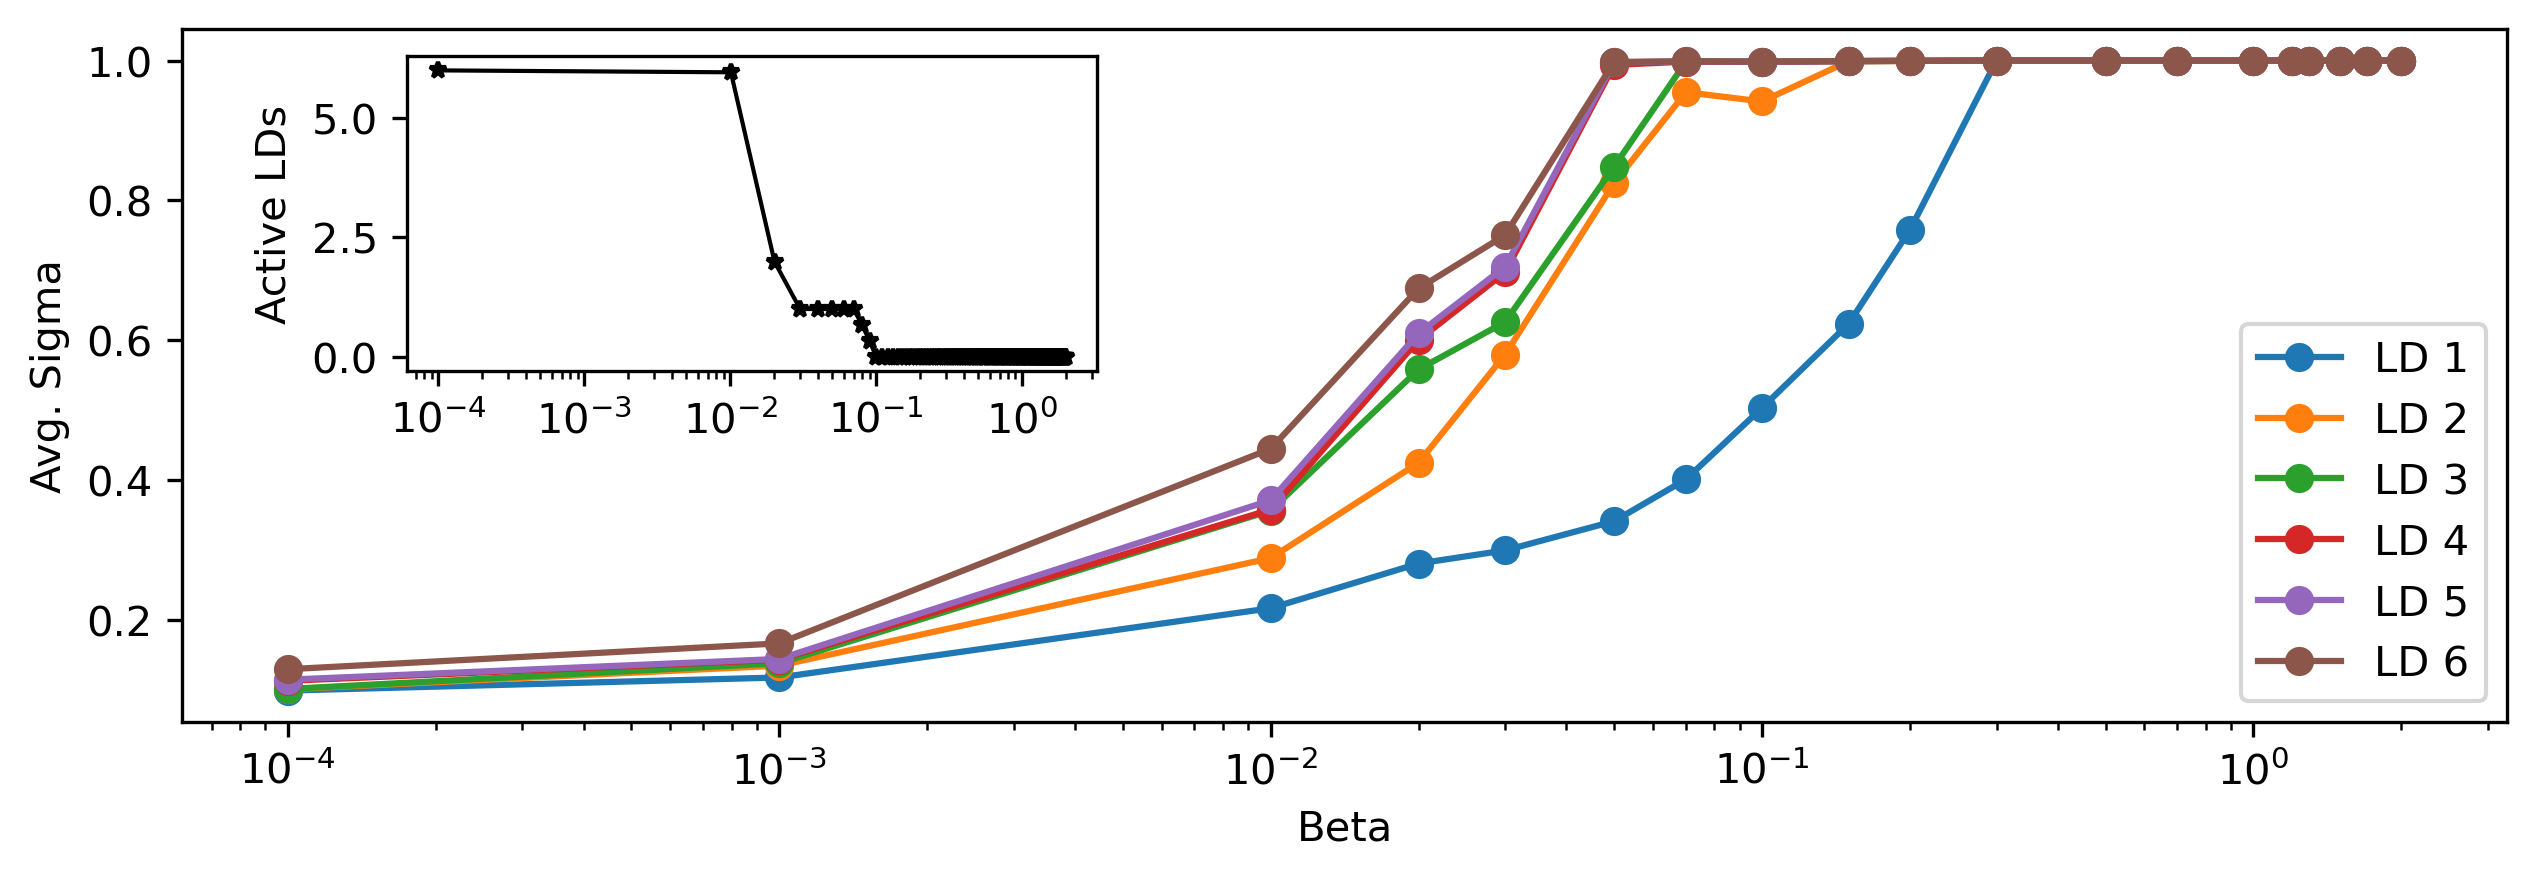

In [14]:
def get_avgSigmas(folder):
    avgSigmas = {}
    for run in [f for f in next(os.walk(folder))[1] if f != 'lightning_logs']:
        n_run = run.split('_')[-1]
        with open(os.path.join(folder,run,'out.txt'), 'r') as f:
            txt = f.readlines()
            ind = len(txt) - 1
            while ind >= 0:
                line = txt[ind]
                if "Avg. Sigma per LD" in line:
                    ind += 1
                    line = txt[ind]
                    values = []
                    while "=====" not in line:
                        infline = line.split(sep=':')
                        key = infline[0].strip()
                        values.append(float(infline[1].strip()))
                        ind += 1
                        line = txt[ind]
                    values = sorted(values)
                    for i, val in enumerate(values):
                        if f"LD {i}" not in avgSigmas.keys():
                            avgSigmas[f"LD {i}"] = {}
                        avgSigmas[f"LD {i}"][n_run] = val
                    break
                ind -= 1
    return avgSigmas

def print_betaSweep(folder):
    plt.close()
    betas = get_sorted(get_betas(folder))
    betas = [float(b) for b in betas]
    avgSigmas = get_avgSigmas(folder)
    for key in avgSigmas.keys():
        avgSigmas[key] = get_sorted(avgSigmas[key])
    # fig, ax = plt.subplots(nrows=2,ncols=1, figsize=(7,6), dpi=300)
    fig, ax = plt.subplots(figsize=(10,3), dpi=300)

    active_lds = []
    for ind,beta in enumerate(betas):
        i = 0
        for key in avgSigmas.keys():
            cs = interp1d(betas, avgSigmas[key], kind='linear')
            if cs(beta) < 0.5:
                i += 1
        active_lds.append(i)
    if True:
        active_lds = [a if a <= 6 else 6 for a in active_lds]

    for key in avgSigmas.keys():
        ld_num  = int(key.split(' ')[-1])
        ax.plot(betas[:len(avgSigmas[key])], avgSigmas[key], 'o-', label="LD " + str(ld_num + 1))
        if ld_num == 5:
            break

    left, bottom, width, height = [0.2, 0.5, 0.23, 0.35]
    ax2 = fig.add_axes([left, bottom, width, height])
    log_betas = np.log(betas)
    multip = [a*b for a,b in zip(betas, active_lds)]
    cs = interp1d(betas, active_lds, kind='linear')
    x_range = np.arange(min(betas), max(betas), 0.01)

    # ax[1].plot(betas, active_lds, 'o-', color='black', label='Active LDs')
    ax2.plot(x_range, cs(x_range), '*-', color='black', label='Active LDs', linewidth=1, markersize=4)
    # ax[1].plot(active_lds, multip, 'o-', color='black', label='Active LDs')

    # ax2.set_xlabel('Beta')
    ax2.set_ylabel('Active LDs')
    # ax2.set_yticks(range(0,7,2))
    ax2.set_xscale('log')
    # ax2.set_yscale('log')

    ax.set_xscale('log')
    ax.set_xlabel('Beta')
    ax.set_ylabel('Avg. Sigma')
    # plt.title(f'{folder.split("/")[-1]}')
    # plt.tight_layout()
    ax.legend(loc='lower right')
    plt.savefig('beta_sweep_solvec_iter8.pdf', dpi=300, bbox_inches='tight')
    plt.show()



print_betaSweep('./beta-sweep_VAE_solvec_ld6_ep500_iter8')

# Read and visualize correlations 

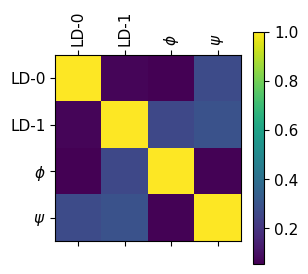

In [70]:
run_folder = "../enhanced_md/run14/iter13/ce_training_1"


def print_correlations(run_folder):
    outfile = os.path.join(run_folder, 'out.txt')
    corr_df = read_correlations_from_file(outfile)
    corr_df = abs(corr_df)
    f = plt.figure(figsize=(3, 3))
    plt.matshow(corr_df, fignum=f.number)
    xticks = [val.replace("phi","$\phi$").replace("psi","$\psi$") for val in corr_df.columns.tolist()]
    yticks = [val.replace("phi","$\phi$").replace("psi","$\psi$") for val in corr_df.index.tolist()]
    plt.xticks(range(corr_df.shape[1]), xticks, fontsize=11, rotation=90)
    plt.yticks(range(corr_df.shape[0]), yticks, fontsize=11)
    cb = plt.colorbar()
    cb.ax.tick_params(labelsize=11)
    plt.savefig('correlations_iter13.pdf', dpi=300, bbox_inches='tight')

print_correlations(run_folder)
